# ME6030 Manipuladores Robóticos

En este notebook puedes encontrar un ejemplo práctico de cinemática inversa.

In [ ]:
%%capture
# Install necessary libraries
!pip install ipywidgets
!pip install matplotlib

In [ ]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

## Herramientas, Clase de transformaciones y generación de poses

In [ ]:
# transformaciones
class Transformations:

    def translation_transform(self,x, y, z):
        return np.array([[1, 0, 0, x], [0, 1, 0, y], [0, 0, 1, z], [0, 0, 0, 1]])

    def rot_x(self, qx):
        return np.array([[1, 0, 0, 0], [0, np.cos(qx), -np.sin(qx), 0], [0, np.sin(qx), np.cos(qx), 0], [0, 0, 0, 1]])

    def rot_y(self, qy):
        return np.array([[np.cos(qy), 0, np.sin(qy), 0], [0, 1, 0, 0], [-np.sin(qy), 0, np.cos(qy), 0], [0, 0, 0, 1]])

    def rot_z(self, qz):

        return np.array([[np.cos(qz), -np.sin(qz), 0, 0], [np.sin(qz), np.cos(qz), 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])


In [ ]:
class PoseGenerator:

    def __init__(self):
        self.fig=None
        self.fig3D = None
        self.ax=None
        self.ax3D=None
        self.escala=2000
    def create_fig3D(self):
            self.fig3D = plt.figure(figsize=(10, 6))
            self.ax3D = self.fig3D.add_subplot(111, projection='3d')
            self.ax3D.axis('equal')
            self.ax3D.set_xlim([-self.escala,self.escala])
            self.ax3D.set_ylim([-self.escala,self.escala])
            self.ax3D.set_zlim([-self.escala,self.escala])
            return self.ax3D, self.fig3D

    def show_fig(self):
        plt.show()

    def draw_axes_tf(self, pose, name="", color="k",marker_length=200):
                self.ax3D.set_title("Kuka")
                origin_pose = np.transpose(pose)[3, 0:3]
                x_rot = np.linalg.multi_dot([pose, [1, 0, 0, 0]])
                y_rot = np.linalg.multi_dot([pose, [0, 1, 0, 0]])
                z_rot = np.linalg.multi_dot([pose, [0, 0, 1, 0]])
                self.ax3D.quiver(origin_pose[0], origin_pose[1], origin_pose[2], x_rot[0],
                        x_rot[1], x_rot[2], length=marker_length, normalize=True, color='r')
                self.ax3D.quiver(origin_pose[0], origin_pose[1], origin_pose[2], y_rot[0],
                        y_rot[1], y_rot[2], length=marker_length, normalize=True, color='g')
                self.ax3D.quiver(origin_pose[0], origin_pose[1], origin_pose[2], z_rot[0],
                        z_rot[1], z_rot[2], length=marker_length, normalize=True, color='b')
                self.ax3D.scatter(xs=[origin_pose[0]], ys=[origin_pose[1]],zs=[origin_pose[2]], marker='o', label=name)
                self.ax3D.legend(loc='upper right', bbox_to_anchor=(1.5, 1))

## Construcción de manipulador Kuka 6DOF (2 links)
  L1 = 675 mm
  L2 = 300 mm
  L3 = 650 mm
  L4 = 155 mm
  L5 = 600 mm
  L6 = 125 mm






In [ ]:
def KUKA(A):

  L1 = 675 #mm
  L2 = 300 #mm
  L3 = 650 #mm
  L4 = 155 #mm
  L5 = 600 #mm
  L6 = 125 #mm
  A1=A[0]
  A2=A[1]
  A3=A[2]
  A4=A[3]
  A5=A[4]
  A6=A[5]

  TF = Transformations()
  Origen = np.identity(4) #pose de origen

  #creamos las transformadas
  T_L1 = TF.translation_transform(0,0,L1)
  Rz_1 = TF.rot_z(A1)
  T_L2 = TF.translation_transform(L2,0,0)
  Ry_2 = TF.rot_y(A2)
  T_L3 = TF.translation_transform(0,0,L3)
  Ry_3 = TF.rot_y(A3)
  T_L4 = TF.translation_transform(L5,0,L4)
  Rx_4 = TF.rot_x(A4)
  Ry_5 = TF.rot_y(A5)
  T_L5 = TF.translation_transform(L6,0,0)
  Rx_6 = TF.rot_x(A6)

  M_o_n = np.linalg.multi_dot([Origen,T_L1,Rz_1,T_L2,Ry_2,T_L3,Ry_3,T_L4, Rx_4, Ry_5, T_L5, Rx_6])
  M_o_n = np.round(M_o_n,2)
  return M_o_n


#Metodo que utiliza KUKA para controlar sus orientaciones
def get_rotation_kuka_abc_from_pose(pose=np.identity(4)):

  if  np.abs(pose[0,0]) < 1e-6 and np.abs(pose[1,0]) < 1e-6:
      beta = np.pi/2
      alfa = 0
      gamma = np.arctan2(pose[0,1],pose[1,1])

  else:
      beta = np.arctan2(-pose[2,0],np.sqrt(pose[0,0]**2+pose[1,0]**2))
      alfa = np.arctan2(pose[1,0],pose[0,0])
      gamma = np.arctan2(pose[2,1],pose[2,2])

  ABC = np.array([np.rad2deg(alfa), np.rad2deg(beta), np.rad2deg(gamma)])

  return ABC


def KUKA_pose_vec(A):    #funcion que retorna vector de configuracion Ai para el kuka
  mon=KUKA(A)
  position = mon[0:3,3]
  ori = get_rotation_kuka_abc_from_pose(mon)
  return np.array([position[0],position[1],position[2],ori[0],ori[1],ori[2]])



## Definamos un metodo para cinematica inversa

Solucion de ángulos [ 1.000e-02  6.715e+01 -2.075e+01  2.300e-01 -4.652e+01 -3.000e-01] 

Matriz Mon KUKA: 
 [[ 1.00e+00  0.00e+00 -0.00e+00  1.55e+03]
 [-0.00e+00  1.00e+00  0.00e+00 -0.00e+00]
 [ 0.00e+00 -0.00e+00  1.00e+00  6.00e+02]
 [ 0.00e+00  0.00e+00  0.00e+00  1.00e+00]]
[-523.97        -21.42        -71.82         -6.98105741   -7.50096449
  -27.08355086]
[-2073.97         -21.42        -671.82          -6.98105741
    -7.50096449   -27.08355086]


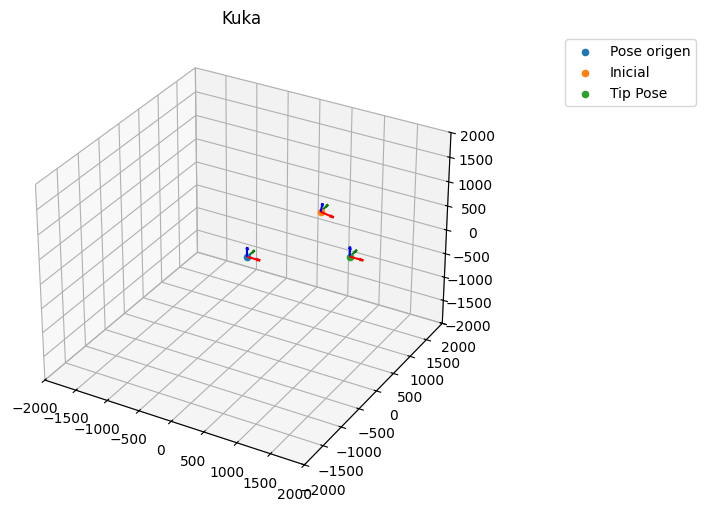

NameError: name 'M_o_n' is not defined

In [ ]:
Pos_Deseada=np.array([1550,0,600,0,0,0]) #X,Y,Z,A,B,C

Vec_A_ini=np.array([0,0.1,0.1,0.1,0,0])

def KUKA_dif(A,x0):    #funcion auxiliar para buscar raices
    return (KUKA_pose_vec(A)-x0)


sol = optimize.fsolve(func=KUKA_dif, x0=Vec_A_ini, args=(Pos_Deseada,))


A_sol = np.array([np.round(np.rad2deg(sol[0]),2),np.round(np.rad2deg(sol[1]),2),np.round(np.rad2deg(sol[2]),2),np.round(np.rad2deg(sol[3]),2),np.round(np.rad2deg(sol[4]),2),np.round(np.rad2deg(sol[5]),2)])
print("Solucion de ángulos",A_sol, "\ n")
print("Matriz Mon KUKA: \n",KUKA(sol))
print(KUKA_pose_vec(A_sol))
print(KUKA_dif(A_sol,Pos_Deseada))

Origen = np.identity(4)
inicial=KUKA(Vec_A_ini)
Final=KUKA(sol)

PG = PoseGenerator()
PG.create_fig3D()
PG.draw_axes_tf(Origen,"Pose origen")
#PG.draw_axes_tf(q1_pose,"q1 Pose")
PG.draw_axes_tf(inicial,"Inicial")
PG.draw_axes_tf(Final,"Final")
PG.show_fig()
print(M_o_n)
